# Spikecurate

_via regression model_

**author**: laquitainesteeve@gmail.com

**purpose**: train a regression model to classify curate the "good" units (>80% agreement score) amongst the sorted single-units, for the biophysical simulation in the evoked regime. 

**tested on**:

* Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

**Method**
- kilosort4's sorting extractor was generated with rtx5090 GPU, so the results slightly change from the original Tesla V100
- a dataset dataframe that contains the sorted single-units (indices), their quality metrics and their quality label ("good" or "bad" units evaluated with our ground truth, columns)

## Setup 

1. Create and activate envs/spikebias.yml

In [16]:
# automatically reload notebook
%load_ext autoreload
%autoreload 2

# import built-in packages
import os
import shutil
import pickle
import copy
import random
import pandas as pd
import spikeinterface as si
import spikeinterface.preprocessing as spre
import spikeinterface.core.template_tools as ttools
from spikeinterface import comparison
from spikeinterface.curation import remove_excess_spikes
from spikeinterface import extract_waveforms
from spikeinterface.postprocessing import compute_principal_components
from spikeinterface.qualitymetrics import compute_quality_metrics as qm
import statsmodels.api as sm
from statsmodels.tools.validation import float_like
import torch
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import seaborn as sns
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import warnings

# silence irrelevant warnings
warnings.filterwarnings("ignore", message="There is no Probe attached to this recording.*")
warnings.filterwarnings("ignore", message="Versions are not the same.*")

# spikeinterface version
print("Spikeinterface", si.__version__)

# set project path
proj_path = "/home/steeve/steeve/epfl/code/spikebias/"
os.chdir(proj_path)

# import custom package
from src.nodes.models.Flc import dataloader
from src.nodes.models.Flc import plotutils as flcplot
from src.nodes.curation import spikecurate
from src.nodes.models.Flc.models import FlcModel # FLC model

# experiment parameters
EXP = "E"
SORTER = "KS4"

# waveform extraction parameters
FREQ_MIN = 300
REFERENCE = "global"
OPERATOR = "median"
MS_BEFORE = 6
MS_AFTER = 6
LOAD_WE = False
DURATION_SEC = 600          # 10 minutes recording
MAX_SPIKES_PER_UNIT = 500   # max number of spikes used per unit
SEED = 0
N_COMP_PCA = 5              # number of pca components
SPARSE = True
OVERWRITE = True
WE_JOB_KWARGS = dict(n_jobs=20, chunk_duration="1s", progress_bar=True)
job_kwargs = dict(n_jobs=-1, progress_bar=True)
CHUNKS = 80000

# model parameters
model_prms = {"seeds": np.arange(0,100,1), "scale_data": False}

# recording extractor
RECORDING_PATH = "dataset/00_raw/recording_npx_evoked/"

# kilosort sorting extractor
SORTING_KS4_PATH = "dataset/01_intermediate/sorting/npx_evoked/SortingKS4_10m/"

# ground truth extractors
SORTING_TRUE = "dataset/00_raw/ground_truth_npx_evoked"
SORTING_TRUE_10mn = "dataset/00_raw/ground_truth_npx_evoked_10m"

# waveform extractors
WE_SINGLE_U_PATH = "dataset/01_intermediate/waveforms/npx_evoked/SortingKS4_10m_single_units"

# unit classification
QUALITY_PATH = "dataset/01_intermediate/analysis/sorting_quality/sorting_quality.csv"

# figure parameters
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6
plt.rcParams["lines.linewidth"] = 0.5
plt.rcParams["axes.linewidth"] = 0.5 
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# figure legend parameters
legend_cfg = {"frameon": False, "handletextpad": 0.5}
tight_layout_cfg = {"pad": 0.001}
LG_FRAMEON = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Spikeinterface 0.100.8


## Load datasets

* Execution time: 27 ms

### Recording extractor

* Execution time: 

In [2]:
%%time

# load and preprocess recording
Recording = si.load_extractor(RECORDING_PATH)
Recording.set_property('location', Recording.get_property('location')[:,:2])
Recording = spre.highpass_filter(Recording, freq_min=FREQ_MIN)
Recording = spre.common_reference(Recording, reference=REFERENCE, operator=OPERATOR)
display(Recording)

CommonReferenceRecording: 384 channels - 20.0kHz - 1 segments - 72,359,964 samples 
                          3,618.00s (1.00 hours) - float32 dtype - 103.51 GiB

CPU times: user 3.92 ms, sys: 997 µs, total: 4.92 ms
Wall time: 7.51 ms


### Ground truth extractor

* Execution time: 

In [3]:
%%time

# load ground truth
SortingTrue = si.load_extractor(SORTING_TRUE)
SortingTrue.frame_slice(start_frame=0, end_frame=Recording.get_sampling_frequency() * DURATION_SEC)
SortingTrue.save(folder=SORTING_TRUE_10mn, overwrite=True)
display(SortingTrue)

NumpyFolderSorting: 1836 units - 1 segments - 20.0kHz

CPU times: user 743 µs, sys: 47.9 ms, total: 48.7 ms
Wall time: 59.8 ms


### Sorting extractor

* Execution time: 20 ms

In [4]:
%%time

# load sorting
Sorting = si.load_extractor(SORTING_KS4_PATH)
Sorting = remove_excess_spikes(Sorting, Recording)
Sorting = Sorting.frame_slice(start_frame=0, end_frame=Recording.get_sampling_frequency() * DURATION_SEC)
display(Sorting)

FrameSliceSorting: 3529 units - 1 segments - 20.0kHz

CPU times: user 1.08 ms, sys: 1.94 ms, total: 3.02 ms
Wall time: 10.2 ms


### Waveform extractor (Sorted units)

* Execution time: 1h47

In [ ]:
%%time 

# select sorted single-units amongst single- and multi-units (KSLABEL="good" for kilosort4)
single_unit_ids = Sorting.unit_ids[np.where(Sorting.get_property("KSLabel") == "good")[0]]
Sorting_single_units = Sorting.select_units(unit_ids=single_unit_ids)

# save their waveforms
We_single_u = extract_waveforms(Recording, Sorting_single_units, WE_SINGLE_U_PATH, mode="folder", sparse=SPARSE, ms_before=MS_BEFORE,
                    ms_after=MS_AFTER, max_spikes_per_unit=MAX_SPIKES_PER_UNIT, unit_batch_size=CHUNKS,
                    overwrite=OVERWRITE, seed=SEED, **WE_JOB_KWARGS)


# save waveform PCA data (the extractor is updated)
pca = compute_principal_components(waveform_extractor=We_single_u, n_components=N_COMP_PCA, mode="by_channel_local", **WE_JOB_KWARGS)

extract waveforms shared_memory multi buffer:   0%|          | 0/3618 [00:00<?, ?it/s]

extract waveforms memmap multi buffer:   0%|          | 0/3618 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/408 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/408 [00:00<?, ?it/s]

CPU times: user 42.6 s, sys: 2min 3s, total: 2min 45s
Wall time: 1h 47min 5s


### Single-unit ids and labels (good/gad)

In [ ]:
%%time

# label "good" and "bad" sorted single-units to train the classifier
good_unit_ids, bad_unit_ids = dataloader.get_good_and_bad_units(QUALITY_PATH, exp=EXP, sorter=SORTER)

# report
print("\nSingle-unit ids:", single_unit_ids)
print("\nGood unit ids:", good_unit_ids)
print("\nBad unit ids:", bad_unit_ids)


Single-unit ids: [1399 1404 1413 1415 1417 1421 1424 1428 1431 1439 1447 1449 1454 1456
 1457 1462 1463 1392 1333 1335 1340 1341 1356 1359 1370 1376 1378 1382
 1384 1386 1388 1389 1394 1571 1574 1576 1577 1579 1581 1584 1586 1587
 1588 1593 1597 1642 1776 1570 1568 1564 1473 1478 1479 1484 1486 1488
 1491 1494 1497 1498 1506 1518 1527 1530 1535 1538 1540 1550 1560 1565
 1331 1330 1320 1249 1255 1264 1265 1271 1272 1278 1280 1281 1284 1293
 1295 1296 1300 1308 1309 1312 1248 1246 1242 1184 1187 1190 1191 1195
 1205 1206 1218 1224 1227 1243 1327 2752 2760 2778 2783 2811 2823 2825
 2849 2865 2872 2889 2923 2924 2925 2927 2928 2969 2971 2972 2982 2985
 3010 3020 2749 3025 2714 2703 2350 2362 2368 2375 2379 2393 2416 2423
 2480 2488 2516 2523 2560 2566 2600 2609 2620 2643 2654 2676 2685 2691
 2698 2707 3030 3038 3049 3343 3345 3353 3356 3357 3381 3382 3384 3385
 3386 3389 3394 3399 3401 3407 3408 3413 3415 3466 3480 3491 3512 3516
 3318 3310 3303 3301 3058 3067 3068 3083 3086 3091 3092 309

### Unit-tests

In [ ]:
%%time

# sanity check units are correct
single_unit_ids_from_file = dataloader.get_sorted_single_unit_ids_from_file(QUALITY_PATH, EXP, SORTER)
assert len(np.intersect1d(single_unit_ids_from_file, single_unit_ids)) == len(single_unit_ids_from_file), "Units are missing or differ"

CPU times: user 5.36 ms, sys: 237 µs, total: 5.6 ms
Wall time: 5.32 ms


In [54]:
Sorting
len(Sorting.unit_ids[np.where(Sorting.get_property("KSLabel") == "good")[0]])
len(single_unit_ids)

408

## Engineer metrics of cell quality

* Execution time: 2 min

In [36]:
%%time

# engineer a dataset of quality metrics (cols) per cell (rows)
data = dataloader.load_dataset(single_unit_ids, good_unit_ids, bad_unit_ids, Sorting_single_units, SortingTrue, We_single_u, load_qm_if_exists=False, delta_time=1.3, job_kwargs=WE_JOB_KWARGS)


Computing spikeinterface quality metrics:


extract amplitudes:   0%|          | 0/3618 [00:00<?, ?it/s]

  0%|          | 0/408 [00:00<?, ?it/s]

****************** Analysing data completion ***************
Data completion: amplitude_cutoff        408
firing_range            408
firing_rate             408
isi_violations_ratio    408
presence_ratio          408
rp_contamination        408
rp_violations           408
sd_ratio                408
snr                     408
silhouette              406
dtype: int64
quality metrics are: Index(['amplitude_cutoff', 'firing_range', 'firing_rate',
       'isi_violations_ratio', 'presence_ratio', 'rp_contamination',
       'rp_violations', 'sd_ratio', 'snr', 'silhouette'],
      dtype='object')

Extracing spike amplitudes:


extract amplitudes:   0%|          | 0/3618 [00:00<?, ?it/s]


Calculating MAD ratios:

Quality metrics used: 
Index(['amplitude_cutoff', 'firing_range', 'firing_rate',
       'isi_violations_ratio', 'presence_ratio', 'rp_contamination',
       'rp_violations', 'sd_ratio', 'snr', 'silhouette', 'mad_ratio'],
      dtype='object')
2026-08-27 21:38:38,413 - root - dataloader.py - load_dataset - INFO - nb of units before filtering units with inf feature: 408
2026-08-27 21:38:38,413 - root - dataloader.py - load_dataset - INFO - nb of units after clearning missing data: 408
CPU times: user 42.6 s, sys: 18.5 s, total: 1min 1s
Wall time: 1min 33s


In [69]:
%%time 

# measure correlations between features (less is better)
data["dataset"].corr()

CPU times: user 181 µs, sys: 280 µs, total: 461 µs
Wall time: 551 µs


,amplitude_cutoff,firing_range,firing_rate,isi_violations_ratio,rp_contamination,rp_violations,sd_ratio,snr,silhouette,mad_ratio,quality_label
amplitude_cutoff,1.000000,-0.202827,-0.198174,-0.057737,-0.039640,-0.041990,0.454293,0.104237,-0.022903,0.393431,-0.192680
firing_range,-0.202827,1.000000,0.992181,0.351541,0.246101,0.297044,-0.211416,0.231682,0.298848,-0.053640,0.353242
firing_rate,-0.198174,0.992181,1.000000,0.364549,0.229586,0.268273,-0.208186,0.233869,0.303105,-0.056621,0.353239
isi_violations_ratio,-0.057737,0.351541,0.364549,1.000000,0.699153,0.606383,-0.082583,0.011443,-0.000288,-0.058354,0.184632
rp_contamination,-0.039640,0.246101,0.229586,0.699153,1.000000,0.939148,-0.039360,0.020503,-0.010474,-0.016606,0.090612
rp_violations,-0.041990,0.297044,0.268273,0.606383,0.939148,1.000000,-0.031466,0.015953,-0.014104,0.004221,0.055228
sd_ratio,0.454293,-0.211416,-0.208186,-0.082583,-0.039360,-0.031466,1.000000,0.153376,-0.098265,0.890382,-0.321326
snr,0.104237,0.231682,0.233869,0.011443,0.020503,0.015953,0.153376,1.000000,0.601140,0.084215,0.486616
silhouette,-0.022903,0.298848,0.303105,-0.000288,-0.010474,-0.014104,-0.098265,0.601140,1.000000,-0.026519,0.576340
mad_ratio,0.393431,-0.053640,-0.056621,-0.058354,-0.016606,0.004221,0.890382,0.084215,-0.026519,1.000000,-0.313424


## Model: train/detect >80% accurate units

quality metrics are: Index(['amplitude_cutoff', 'firing_range', 'firing_rate',
       'isi_violations_ratio', 'presence_ratio', 'rp_contamination',
       'rp_violations', 'sd_ratio', 'snr', 'silhouette'],
      dtype='object')

CPU times: user 1.24 s, sys: 0 ns, total: 1.24 s
Wall time: 1.24 s


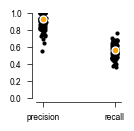

In [70]:
%%time

# instantiate the model
flcmodel = FlcModel(data["predictors"])

# train & eval. w/ cross-val.
results = flcmodel.evaluate(data["dataset"], **model_prms)

# plot
fig, ax = plt.subplots(1, 1, figsize=(1.1, 1.1))
ax = flcplot.plot(ax, results["metric_data"])

### Train & eval

* z-scoring the features marginally changed the results. So we used the raw data, to produce more interpretable weights.

#### Z-scored


precision:
median: 0.875
std: 0.09950912578759508
95% CI: 0.019503788654368633

recall:
median r2: 0.56
std r2: 0.13126435191527583
95% CI: 0.02572781297539406


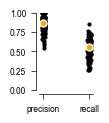

In [71]:
# parameters
seeds = np.arange(0, 100, 1)

# curate dataset
dataset_c = copy.copy(data["dataset"])

# (10s) evaluate
precisions, recalls = spikecurate.train_test_eval(flcmodel.formula, dataset_c, seeds, scale_data=True)

#### Raw


precision:
median: 0.9230769230769231
std: 0.08904481484467007
95% CI: 0.017452783709555334

recall:
median r2: 0.5577777777777778
std r2: 0.07852445118397032
95% CI: 0.015390792432058181


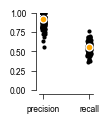

In [72]:
# curate dataset
dataset_c = copy.copy(data["dataset"])

# (10s) evaluate
precisions, recalls = spikecurate.train_test_eval(flcmodel.formula, dataset_c, seeds, scale_data=False)